In [1]:
import json
import heapq
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe


### Assignment 1 ###

#### Part 1 Finding a Shortest Path with An Energy Budget ####

First we define some useful helper functions

In [12]:
def read_json(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data #This will return a dictionary

def get_neighbours(G, V):
    return G[V]

def get_dist(dict, edge_key):
    return dict[edge_key]

def get_cost(dict, edge_key):
    return dict[edge_key]


In [6]:
graph = read_json('G.json')
distances = read_json('Dist.json')
costs = read_json('Cost.json')
coordinates = read_json('Coord.json')

### Task 1
Here, we will solve a relaxed version of the NYC instance where we do not have the energy
constraint. 

From the lectures, the most suitable algortihm for this task is the **Uniform Cost Search** algorithm, more specifically Dijkstra's algorithm as this task requires us to find the shortest paths, without energy constraints.

UCS is an uninformed (blind) best-first search that always expands the node with the lowest cumulative path cost from the start so far. Because it explores paths in strictly increasing order of cost and never re-expands nodes once their optimal cost is found (assuming non-negative edge weights), **the first time the goal is dequeued/selected, the path to it is guaranteed to be optimal** (shortest).  
This matches the task perfectly where we need the mathematically shortest path, not just any feasible one.

In [ ]:
def UniformCostSearch(graph, Dist, Cost, start='1', target='50'):
    # Priority queue stores tuples of (accumulated_distance, current_node)
    pq = [(0, start)]
    
    # Dictionary to track the shortest distance to each node found so far
    # Initialize all with infinity except the start node
    shortest_distances = {node: float('inf') for node in graph}
    shortest_distances[start] = 0
    
    # Dictionary to track the path (parent pointers)
    parent = {start: None}
    
    while pq:
        current_dist, current_node = heapq.heappop(pq)
        
        # If we reached the target, we can stop searching
        if current_node == target:
            break
            
        # If we pulled a suboptimal path from the queue, ignore it
        if current_dist > shortest_distances[current_node]:
            continue
            
        # Explore neighbors using the adjacency list G [cite: 49]
        for neighbor in get_neighbours(graph, current_node):

            edge_key = f"{current_node},{neighbor}"
            
            if edge_key not in distances:
                edge_key = f"{neighbor},{current_node}"
            
            weight = get_dist(Dist, edge_key)
            distance = current_dist + weight
            
            # If we found a strictly shorter path to the neighbor, update it
            if distance < shortest_distances[neighbor]:
                shortest_distances[neighbor] = distance
                parent[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))
                
    # Construct the path
    path = []
    curr = target
    while curr is not None:
        path.append(curr)
        curr = parent.get(curr)
    path.reverse() # Reverse to get the path from start -> target
    
    # --- Calculate Total Energy Cost ---
    # Even though we ignored energy during the search, the output requires it
    total_energy = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_key = f"{u},{v}"
        if edge_key not in Cost:
            edge_key = f"{v},{u}"
        total_energy += get_cost(Cost, edge_key) # Access energy cost using Cost['v,w'] [cite: 55]

    return path, shortest_distances[target], total_energy

In [24]:
path, total_dist, total_energy = UniformCostSearch(graph, distances, costs, '1', '50')
path_str = "->".join(path)
print(f"Shortest path: {path_str}.")
print(f"Shortest distance: {total_dist}.")
print(f"Total energy cost: {total_energy}.")

Shortest path: 1->1363->1358->1357->1356->1276->1273->1277->1269->1267->1268->1284->1283->1282->1255->1253->1260->1259->1249->1246->963->964->962->1002->952->1000->998->994->995->996->987->988->979->980->969->977->989->990->991->2369->2366->2340->2338->2339->2333->2334->2329->2029->2027->2019->2022->2000->1996->1997->1993->1992->1989->1984->2001->1900->1875->1874->1965->1963->1964->1923->1944->1945->1938->1937->1939->1935->1931->1934->1673->1675->1674->1837->1671->1828->1825->1817->1815->1634->1814->1813->1632->1631->1742->1741->1740->1739->1591->1689->1585->1584->1688->1579->1679->1677->104->5680->5418->5431->5425->5424->5422->5413->5412->5411->66->5392->5391->5388->5291->5278->5289->5290->5283->5284->5280->50.
Shortest distance: 148648.63722140007.
Total energy cost: 294853.


#### Part 2 Solving MDP and Reinforcement Learning Problems Using a Grid World ####

## Stochastic Grid World Environment (5×5)

This class implements a **5×5 grid world** reinforcement learning environment with the following features:

- **Start state**: (0, 0) — bottom-left corner
- **Goal state**: (4, 4) — top-right corner (reward = **+10**)
- **Roadblocks** (impassable cells): (2,1) and (2,3)
- **Actions**: UP, DOWN, LEFT, RIGHT
- **Movement is stochastic**:
  - 80% chance: intended direction
  - 10% chance: slip left (perpendicular)
  - 10% chance: slip right (perpendicular)
- Every step that does **not** reach the goal gives **-1** reward (living penalty)
- Hitting a wall or roadblock → agent stays in place
- Episode ends when the agent reaches the goal

### Key Methods

| Method              | Purpose                                                                 |
|---------------------|-------------------------------------------------------------------------|
| `reset()`           | Move agent back to start → returns starting state                       |
| `get_current_state()` | Return agent's current position                                       |
| `is_goal(state)`    | Check if state is the goal                                              |
| `reward_for(state)` | +10 if goal, -1 otherwise                                               |
| `move(state, action)` | Compute deterministic next position (respects walls & roadblocks)    |
| `step(action)`      | Execute one step with stochastic slipping → returns `(next_state, reward, done)` |

### Environment Summary

- Grid size: **5×5** (25 cells total)
- Blocked cells: **2** → 23 valid states

In [3]:
import random

class GridWorld:
    def __init__(self):
        self.n_rows = 5
        self.n_cols = 5
        self.start = (0, 0)
        self.goal = (4, 4)
        
        self.roadblocks = {(2, 1), (2, 3)}
        
        self.states = [(r, c) for r in range(self.n_rows) 
                      for c in range(self.n_cols) 
                      if (r, c) not in self.roadblocks]
        
        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def get_current_state(self):
        return self.state

    def is_goal(self, state):
        return state == self.goal

    def reward_for(self, state):
        return 10 if state == self.goal else -1

    def move(self, state, action): 
        r, c = state
        
        moves = {
            'UP':    (1, 0),
            'DOWN':  (-1, 0),
            'LEFT':  (0, -1),
            'RIGHT': (0, 1)
        }
        
        dr, dc = moves[action]
        new_r, new_c = r + dr, c + dc
        new_pos = (new_r, new_c)
        
        if (0 <= new_r < self.n_rows and 
            0 <= new_c < self.n_cols and 
            new_pos not in self.roadblocks):
            return new_pos
            
        return state

    def step(self, action): 
        slips = {
            'UP':    ['LEFT', 'RIGHT'],
            'DOWN':  ['LEFT', 'RIGHT'],
            'LEFT':  ['UP', 'DOWN'],
            'RIGHT': ['UP', 'DOWN']
        }
        
        options = [action, *slips[action]]
        actual = random.choices(options, weights=[0.8, 0.1, 0.1])[0]
        
        next_state = self.move(self.state, actual)
        reward = self.reward_for(next_state)
        done = self.is_goal(next_state)
        
        self.state = next_state
        
        return next_state, reward, done

In [4]:
grid = GridWorld()
grid.get_current_state()

(0, 0)

In [11]:
Q_table = {state: {action: 0.0 for action in grid.actions} for state in grid.states}
V_table = {state: 0.0 for state in grid.states}

In [6]:
def Bellman(state, action, env, V_table, gamma=0.9):
    # If the current state is already the goal, there is no future value to calculate
    if env.is_goal(state):
        return 0.0
        
    possible_actions = {
        'UP': ['LEFT', 'RIGHT'],
        'DOWN': ['LEFT', 'RIGHT'],
        'LEFT': ['UP', 'DOWN'],
        'RIGHT': ['UP', 'DOWN']
    }
    
    # Map out the possible actions and their respective transition probabilities
    actions_probs = [
        (action, 0.8), 
        (possible_actions[action][0], 0.1), 
        (possible_actions[action][1], 0.1)
    ]
    
    expected_value = 0.0
    
    for act, prob in actions_probs:
        # Determine where this specific movement actually lands you
        next_state = env.move(state, act)
        
        # Determine the reward: +10 for goal, -1 for step
        reward = env.reward_for(next_state)
        
        # Terminal states have a future value of 0, otherwise fetch from V_table
        if env.is_goal(next_state):
            future_value = 0.0
        else:
            future_value = V_table[next_state]
            
        #accumulate values with Bellman formula
        expected_value += prob * (reward + gamma * future_value)
        
    return expected_value



#### Value iteration

In [14]:
theta = 0.0001  # Convergence threshold
iteration = 0

while True:
    delta = 0  # Reset delta for the new sweep
    new_V_table = V_table.copy() # Create a temporary table for the new values
    
    for state in grid.states:
        # The goal state is terminal and its value stays 0.0
        if grid.is_goal(state):
            continue 
            
        result = []
        for action in grid.actions:
            value = Bellman(state=state, action=action, env=grid, V_table=V_table)
            Q_table[state][action] = value
            result.append(value)  
            
        max_val = max(result)
        
        # Update delta by checking how much this specific state's value changed
        delta = max(delta, abs(V_table[state] - max_val))
        
        new_V_table[state] = max_val

    V_table = new_V_table # Update the original V_table with the new values
    iteration += 1
    
    print(f"Iteration {iteration} finished. Max change (delta): {delta}")
    
    # Stop the loop if the changes are tiny enough
    if delta < theta:
        print(f"\nConvergence reached after {iteration} iterations!")
        break

Iteration 1 finished. Max change (delta): 7.800000000000001
Iteration 2 finished. Max change (delta): 6.228000000000001
Iteration 3 finished. Max change (delta): 4.8924
Iteration 4 finished. Max change (delta): 3.7873008000000006
Iteration 5 finished. Max change (delta): 2.891248992000001
Iteration 6 finished. Max change (delta): 1.9902063916800006
Iteration 7 finished. Max change (delta): 1.5373729321344003
Iteration 8 finished. Max change (delta): 1.1957183734187522
Iteration 9 finished. Max change (delta): 0.7517956936002497
Iteration 10 finished. Max change (delta): 0.6290746390242834
Iteration 11 finished. Max change (delta): 0.34848235797428595
Iteration 12 finished. Max change (delta): 0.19753219050827253
Iteration 13 finished. Max change (delta): 0.09907244639224833
Iteration 14 finished. Max change (delta): 0.049255050801288336
Iteration 15 finished. Max change (delta): 0.023243055234757115
Iteration 16 finished. Max change (delta): 0.010840691787550094
Iteration 17 finished. 

In [16]:
V_table

{(0, 0): -1.9032027083453706,
 (0, 1): -0.9706502347042238,
 (0, 2): 0.1568402482517487,
 (0, 3): 1.3142408871303863,
 (0, 4): 2.7110685991835437,
 (1, 0): -0.8951678107261486,
 (1, 1): 0.042370131178411014,
 (1, 2): 1.56379220807409,
 (1, 3): 2.7110685991835437,
 (1, 4): 4.651102313687335,
 (2, 0): 0.25221782509587376,
 (2, 2): 3.216648014310463,
 (2, 4): 6.928482840108147,
 (3, 0): 1.676142575928155,
 (3, 1): 3.3502492024745414,
 (3, 2): 5.052293788509418,
 (3, 3): 7.161016946120795,
 (3, 4): 9.27966101593857,
 (4, 0): 2.6807201192046968,
 (4, 1): 4.567504209184949,
 (4, 2): 6.742925667228326,
 (4, 3): 9.27966101593857,
 (4, 4): 0.0}

In [17]:
Q_table

{(0, 0): {'UP': -1.9032027083453706,
  'DOWN': -2.6290245689493124,
  'LEFT': -2.6222279714587486,
  'RIGHT': -1.9507788907793164},
 (0, 1): {'UP': -1.1266999846875492,
  'DOWN': -1.856098068519666,
  'LEFT': -2.4539186733853686,
  'RIGHT': -0.9706502347042238},
 (0, 2): {'UP': 0.1568402482517487,
  'DOWN': -0.8561801176308862,
  'LEFT': -1.5440619679491936,
  'RIGHT': 0.1010970524696246},
 (0, 3): {'UP': 1.2100734293282482,
  'DOWN': 0.20435212729107954,
  'LEFT': -0.5248200773238878,
  'RIGHT': 1.3142408871303863},
 (0, 4): {'UP': 2.7110685991835437,
  'DOWN': 1.3142408871303863,
  'LEFT': 0.6088382118545085,
  'RIGHT': 1.614559513891677},
 (1, 0): {'UP': -0.8951678107261486,
  'DOWN': -2.447122075894805,
  'LEFT': -1.7931395602842175,
  'RIGHT': -1.1181142563766104},
 (1, 1): {'UP': -0.9093447063767272,
  'DOWN': -1.638742790208844,
  'LEFT': -1.7280968127814271,
  'RIGHT': 0.042370131178411014},
 (1, 2): {'UP': 1.56379220807409,
  'DOWN': -0.6392901943972255,
  'LEFT': -0.665906129

#### Deriving the optimal policy $\pi^*(s)$ from a Q-table, 
we select the action with the highest Q-value for each state: $\pi^*(s) = \arg\max_a Q(s, a)$.

In [18]:
optimal_policy = {}

# Loop through every state and its corresponding dictionary of action values
for state, actions in Q_table.items():
    
    # actions.get returns the Q-value, so max() finds the action string with the highest value
    best_action = max(actions, key=actions.get)
    
    # Store the best action in our policy dictionary
    optimal_policy[state] = best_action

# Print out the final policy in a readable format
print("Derived Optimal Policy:")
for state, action in optimal_policy.items():
    print(f"State {state}: {action}")

Derived Optimal Policy:
State (0, 0): UP
State (0, 1): RIGHT
State (0, 2): UP
State (0, 3): RIGHT
State (0, 4): UP
State (1, 0): UP
State (1, 1): RIGHT
State (1, 2): UP
State (1, 3): RIGHT
State (1, 4): UP
State (2, 0): UP
State (2, 2): UP
State (2, 4): UP
State (3, 0): RIGHT
State (3, 1): RIGHT
State (3, 2): RIGHT
State (3, 3): RIGHT
State (3, 4): UP
State (4, 0): RIGHT
State (4, 1): RIGHT
State (4, 2): RIGHT
State (4, 3): RIGHT
State (4, 4): UP


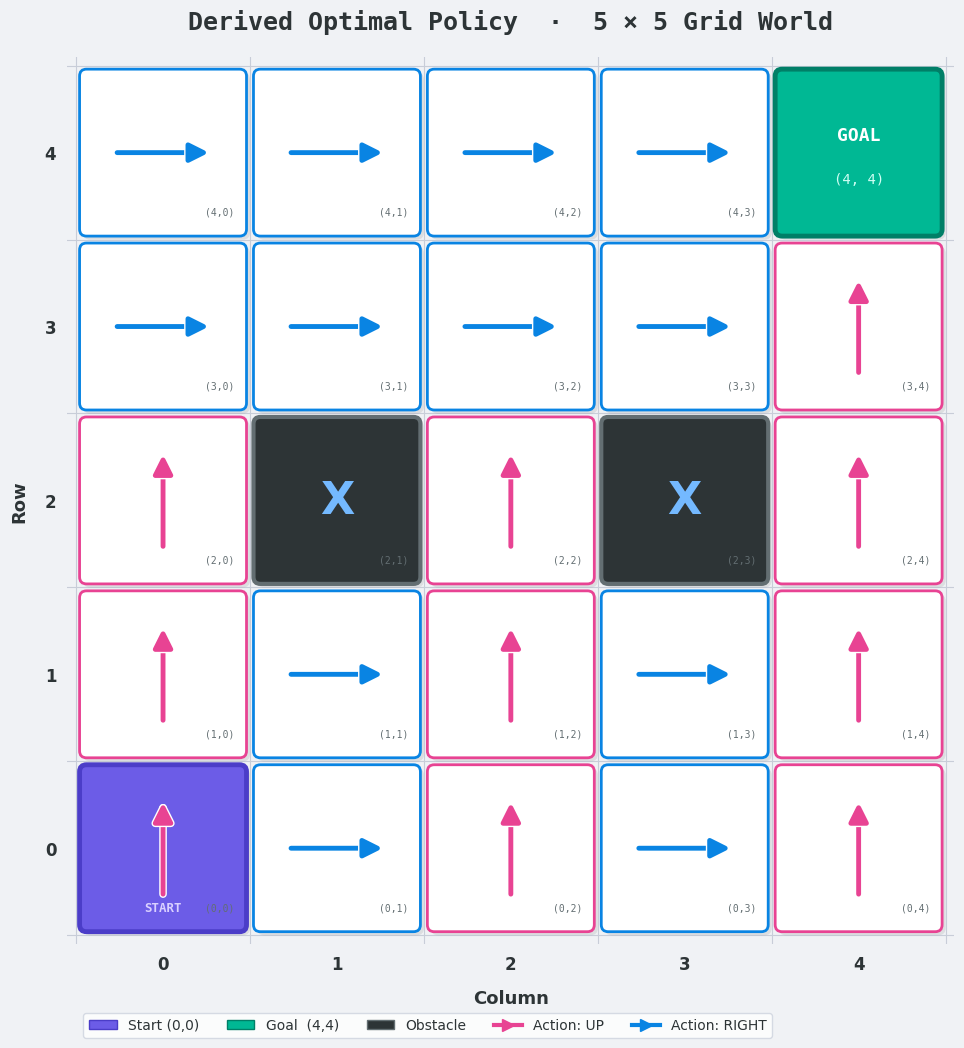

In [35]:
policy = optimal_policy

OBSTACLES  = {(2, 1), (2, 3)}
START      = (0, 0)
GOAL       = (4, 4)
GRID       = 5

BG          = '#F0F2F5'
CELL_BG     = '#FFFFFF'
UP_COLOR    = '#E84393'
RIGHT_COLOR = '#0984E3'
OBS_FACE    = '#2D3436'
OBS_EDGE    = '#636E72'
START_FACE  = '#6C5CE7'
START_EDGE  = '#4B3DC8'
GOAL_FACE   = '#00B894'
GOAL_EDGE   = '#007F67'
COORD_COLOR = '#636E72'

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

def draw_cell(ax, x, y, facecolor, edgecolor, lw=2.5):
    shadow = FancyBboxPatch((x+0.08, y+0.04), 0.88, 0.88,
        boxstyle="round,pad=0.04", facecolor='#00000015', edgecolor='none', zorder=1)
    ax.add_patch(shadow)
    rect = FancyBboxPatch((x+0.06, y+0.06), 0.88, 0.88,
        boxstyle="round,pad=0.04", facecolor=facecolor, edgecolor=edgecolor,
        linewidth=lw, zorder=2)
    ax.add_patch(rect)

def draw_arrow(ax, x, y, action, color):
    s = (x+0.5, y+0.22) if action == 'UP' else (x+0.22, y+0.5)
    e = (x+0.5, y+0.78) if action == 'UP' else (x+0.78, y+0.5)
    arrow = FancyArrowPatch(s, e, arrowstyle='-|>', mutation_scale=28,
        color=color, linewidth=3.5, zorder=4,
        path_effects=[pe.withStroke(linewidth=5.5, foreground='white')])
    ax.add_patch(arrow)

for row in range(GRID):
    for col in range(GRID):
        x, y = col, row

        if (row, col) in OBSTACLES:
            draw_cell(ax, x, y, OBS_FACE, OBS_EDGE, lw=3)
            ax.text(x+0.5, y+0.5, 'X', fontsize=32, ha='center', va='center',
                    color='#74B9FF', fontweight='bold', zorder=5)

        elif (row, col) == GOAL:
            draw_cell(ax, x, y, GOAL_FACE, GOAL_EDGE, lw=3.5)
            ax.text(x+0.5, y+0.60, 'GOAL', fontsize=13, ha='center', va='center',
                    color='white', fontweight='bold', zorder=5, fontfamily='monospace')
            ax.text(x+0.5, y+0.35, '(4, 4)', fontsize=10, ha='center', va='center',
                    color='#D0FFF4', zorder=5, fontfamily='monospace')

        elif (row, col) == START:
            draw_cell(ax, x, y, START_FACE, START_EDGE, lw=3.5)
            action = policy[START]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_arrow(ax, x, y, action, color)
            ax.text(x+0.5, y+0.16, 'START', fontsize=9, ha='center', va='center',
                    color='#D9D0FF', fontweight='bold', zorder=6, fontfamily='monospace')

        elif (row, col) in policy:
            action = policy[(row, col)]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_cell(ax, x, y, CELL_BG, color, lw=2)
            draw_arrow(ax, x, y, action, color)

        if (row, col) != GOAL:
            ax.text(x+0.91, y+0.13, f'({row},{col})', fontsize=7,
                    ha='right', va='bottom', color=COORD_COLOR, zorder=6,
                    fontfamily='monospace')

for i in range(GRID + 1):
    ax.axhline(i, color='#C8CDD8', linewidth=0.8, zorder=0)
    ax.axvline(i, color='#C8CDD8', linewidth=0.8, zorder=0)

ax.set_xlim(-0.05, GRID + 0.05)
ax.set_ylim(-0.05, GRID + 0.05)
ax.set_aspect('equal')
ax.set_xticks([i + 0.5 for i in range(GRID)])
ax.set_yticks([i + 0.5 for i in range(GRID)])
ax.set_xticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.set_yticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.tick_params(length=0, pad=8)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Column", fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_ylabel("Row",    fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_title("Derived Optimal Policy  ·  5 × 5 Grid World",
             fontsize=18, fontweight='bold', color='#2D3436', pad=20, fontfamily='monospace')

legend_elements = [
    mpatches.Patch(facecolor=START_FACE, edgecolor=START_EDGE, label='Start (0,0)'),
    mpatches.Patch(facecolor=GOAL_FACE,  edgecolor=GOAL_EDGE,  label='Goal  (4,4)'),
    mpatches.Patch(facecolor=OBS_FACE,   edgecolor=OBS_EDGE,   label='Obstacle'),
    Line2D([0],[0], color=UP_COLOR,    linewidth=3, label='Action: UP',    marker='>', markersize=8),
    Line2D([0],[0], color=RIGHT_COLOR, linewidth=3, label='Action: RIGHT', marker='>', markersize=8),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, -0.07),
          ncol=5, frameon=True, fontsize=10, facecolor='white',
          edgecolor='#CDD3DE', labelcolor='#2D3436')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### Policy iteration

In [23]:
def policy_evaluation(env, policy, V_table, gamma=0.9, theta=1e-4):
    """Step 1: Calculate the exact V_table for the current policy."""
    while True:
        delta = 0
        new_V_table = V_table.copy()
        
        for state in env.states:
            if env.is_goal(state):
                continue
                
            # Only evaluate the specific action dictated by the current policy
            action = policy[state]
            value = Bellman(state, action, env, V_table, gamma)
            
            delta = max(delta, abs(V_table[state] - value))
            new_V_table[state] = value
            
        V_table = new_V_table
        if delta < theta:
            break # The values for this specific policy have converged
            
    return V_table

In [24]:
def policy_improvement(env, policy, V_table, gamma=0.9):
    """Step 2: Greedily update the policy based on the new V_table."""
    policy_stable = True #flag to check if any policy changes occur
    
    for state in env.states:
        if env.is_goal(state):
            continue
            
        old_action = policy[state]
        
        # Check all possible actions to see if one is better than the current one
        max_val = float('-inf')
        best_action = None
        
        for action in env.actions:
            value = Bellman(state, action, env, V_table, gamma)
            if value > max_val:
                max_val = value
                best_action = action
                
        # Update the policy
        policy[state] = best_action
        
        # If the action changed, our policy hasn't settled yet
        if old_action != best_action:
            policy_stable = False
            
    return policy, policy_stable

In [25]:
def policy_iteration(env, gamma=0.9, theta=1e-4):
    """The main loop tying it all together."""
    # Initialize a V_table of 0.0s and an arbitrary starting policy (e.g., always go UP)
    V_table = {state: 0.0 for state in env.states}
    policy = {state: 'UP' for state in env.states} 
    
    iteration = 0
    while True:
        iteration += 1
        
        # 1. Evaluate
        V_table = policy_evaluation(env, policy, V_table, gamma, theta)
        
        # 2. Improve
        policy, policy_stable = policy_improvement(env, policy, V_table, gamma)
        
        if policy_stable:
            print(f"Policy Iteration converged after {iteration} full loops!")
            break
            
    return V_table, policy

In [27]:
env = GridWorld()
final_V_PI, final_Policy_PI = policy_iteration(env)
print("Final policy derived from Policy Iteration:")
for state, action in final_Policy_PI.items():
    print(f"State {state}: {action}")

Policy Iteration converged after 4 full loops!
Final policy derived from Policy Iteration:
State (0, 0): UP
State (0, 1): RIGHT
State (0, 2): UP
State (0, 3): RIGHT
State (0, 4): UP
State (1, 0): UP
State (1, 1): RIGHT
State (1, 2): UP
State (1, 3): RIGHT
State (1, 4): UP
State (2, 0): UP
State (2, 2): UP
State (2, 4): UP
State (3, 0): RIGHT
State (3, 1): RIGHT
State (3, 2): RIGHT
State (3, 3): RIGHT
State (3, 4): UP
State (4, 0): RIGHT
State (4, 1): RIGHT
State (4, 2): RIGHT
State (4, 3): RIGHT
State (4, 4): UP


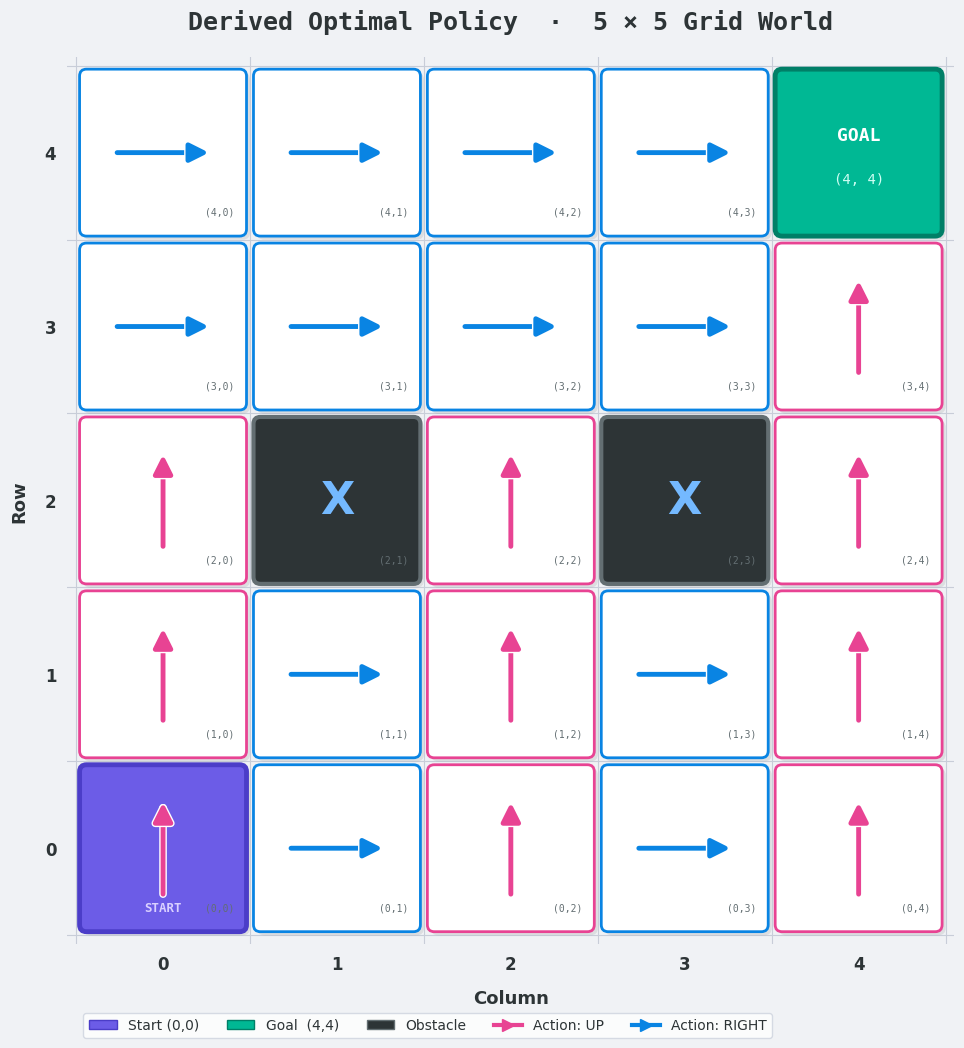

In [36]:
policy = final_Policy_PI

OBSTACLES  = {(2, 1), (2, 3)}
START      = (0, 0)
GOAL       = (4, 4)
GRID       = 5

BG          = '#F0F2F5'
CELL_BG     = '#FFFFFF'
UP_COLOR    = '#E84393'
RIGHT_COLOR = '#0984E3'
OBS_FACE    = '#2D3436'
OBS_EDGE    = '#636E72'
START_FACE  = '#6C5CE7'
START_EDGE  = '#4B3DC8'
GOAL_FACE   = '#00B894'
GOAL_EDGE   = '#007F67'
COORD_COLOR = '#636E72'

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

def draw_cell(ax, x, y, facecolor, edgecolor, lw=2.5):
    shadow = FancyBboxPatch((x+0.08, y+0.04), 0.88, 0.88,
        boxstyle="round,pad=0.04", facecolor='#00000015', edgecolor='none', zorder=1)
    ax.add_patch(shadow)
    rect = FancyBboxPatch((x+0.06, y+0.06), 0.88, 0.88,
        boxstyle="round,pad=0.04", facecolor=facecolor, edgecolor=edgecolor,
        linewidth=lw, zorder=2)
    ax.add_patch(rect)

def draw_arrow(ax, x, y, action, color):
    s = (x+0.5, y+0.22) if action == 'UP' else (x+0.22, y+0.5)
    e = (x+0.5, y+0.78) if action == 'UP' else (x+0.78, y+0.5)
    arrow = FancyArrowPatch(s, e, arrowstyle='-|>', mutation_scale=28,
        color=color, linewidth=3.5, zorder=4,
        path_effects=[pe.withStroke(linewidth=5.5, foreground='white')])
    ax.add_patch(arrow)

for row in range(GRID):
    for col in range(GRID):
        x, y = col, row

        if (row, col) in OBSTACLES:
            draw_cell(ax, x, y, OBS_FACE, OBS_EDGE, lw=3)
            ax.text(x+0.5, y+0.5, 'X', fontsize=32, ha='center', va='center',
                    color='#74B9FF', fontweight='bold', zorder=5)

        elif (row, col) == GOAL:
            draw_cell(ax, x, y, GOAL_FACE, GOAL_EDGE, lw=3.5)
            ax.text(x+0.5, y+0.60, 'GOAL', fontsize=13, ha='center', va='center',
                    color='white', fontweight='bold', zorder=5, fontfamily='monospace')
            ax.text(x+0.5, y+0.35, '(4, 4)', fontsize=10, ha='center', va='center',
                    color='#D0FFF4', zorder=5, fontfamily='monospace')

        elif (row, col) == START:
            draw_cell(ax, x, y, START_FACE, START_EDGE, lw=3.5)
            action = policy[START]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_arrow(ax, x, y, action, color)
            ax.text(x+0.5, y+0.16, 'START', fontsize=9, ha='center', va='center',
                    color='#D9D0FF', fontweight='bold', zorder=6, fontfamily='monospace')

        elif (row, col) in policy:
            action = policy[(row, col)]
            color  = UP_COLOR if action == 'UP' else RIGHT_COLOR
            draw_cell(ax, x, y, CELL_BG, color, lw=2)
            draw_arrow(ax, x, y, action, color)

        if (row, col) != GOAL:
            ax.text(x+0.91, y+0.13, f'({row},{col})', fontsize=7,
                    ha='right', va='bottom', color=COORD_COLOR, zorder=6,
                    fontfamily='monospace')

for i in range(GRID + 1):
    ax.axhline(i, color='#C8CDD8', linewidth=0.8, zorder=0)
    ax.axvline(i, color='#C8CDD8', linewidth=0.8, zorder=0)

ax.set_xlim(-0.05, GRID + 0.05)
ax.set_ylim(-0.05, GRID + 0.05)
ax.set_aspect('equal')
ax.set_xticks([i + 0.5 for i in range(GRID)])
ax.set_yticks([i + 0.5 for i in range(GRID)])
ax.set_xticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.set_yticklabels([str(i) for i in range(GRID)], fontsize=12, fontweight='bold', color='#2D3436')
ax.tick_params(length=0, pad=8)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Column", fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_ylabel("Row",    fontsize=13, fontweight='bold', color='#2D3436', labelpad=12)
ax.set_title("Derived Optimal Policy  ·  5 × 5 Grid World",
             fontsize=18, fontweight='bold', color='#2D3436', pad=20, fontfamily='monospace')

legend_elements = [
    mpatches.Patch(facecolor=START_FACE, edgecolor=START_EDGE, label='Start (0,0)'),
    mpatches.Patch(facecolor=GOAL_FACE,  edgecolor=GOAL_EDGE,  label='Goal  (4,4)'),
    mpatches.Patch(facecolor=OBS_FACE,   edgecolor=OBS_EDGE,   label='Obstacle'),
    Line2D([0],[0], color=UP_COLOR,    linewidth=3, label='Action: UP',    marker='>', markersize=8),
    Line2D([0],[0], color=RIGHT_COLOR, linewidth=3, label='Action: RIGHT', marker='>', markersize=8),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, -0.07),
          ncol=5, frameon=True, fontsize=10, facecolor='white',
          edgecolor='#CDD3DE', labelcolor='#2D3436')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

#### Comparing the policies

In [34]:
# Policy 1 (Value iteration Policy)
policy1 = optimal_policy
# Policy 2 (Policy Iteration Result)
policy2 = final_Policy_PI

# Compare policies
differences = []

all_states = set(policy1.keys()).union(set(policy2.keys()))

for state in sorted(all_states):
    action1 = policy1.get(state)
    action2 = policy2.get(state)
    
    if action1 != action2:
        differences.append((state, action1, action2))

# Print results
if not differences:
    print("The two policies are IDENTICAL.")
    print("Total states compared:", len(all_states))
    print("Number of differences found:", len(differences))
else:
    print("Policies are NOT identical.")
    print("Differences found:\n")
    for state, a1, a2 in differences:
        print(f"State {state}: Policy1={a1}, Policy2={a2}")

The two policies are IDENTICAL.
Total states compared: 23
Number of differences found: 0


The policy derived from Policy Iteration is identical to the previously computed optimal policy. All 23 non-obstacle states have matching actions, confirming convergence to the same optimal solution. Policy Iteration required 4 full evaluation-improvement cycles to stabilize, demonstrating correct implementation and convergence behavior in this stochastic GridWorld MDP.